# Tugas B-2: Aspect-Based Level Sentiment Analysis
**Dataset: Berita LPDP (1.038 artikel, Maret 2026)**

Notebook ini mencakup:
- Q1: Perbedaan SA biasa vs ABSA
- Q2: Tahapan preprocessing (dengan ilustrasi kode)
- Q3: Identifikasi aspect term & polaritas
- Q4: Contoh anotasi ABSA
- Q5: Lexicon vs ML
- Q6: Implementasi ABSA lexicon + IndoBERT
---

## Q1. Perbedaan Sentiment Analysis Biasa dan ABSA

Sentiment analysis biasa memberikan **satu label** per dokumen. ABSA memberikan **label per aspek** yang dibahas dalam teks.

| Dimensi | SA Biasa | ABSA |
|---------|----------|------|
| Granularitas | Dokumen | Per aspek |
| Output | 1 label | N label (1 per aspek) |
| Contoh LPDP | 'Artikel Negatif' | 'Seleksi: Negatif \| Kebijakan: Positif' |

Pada dataset ini: label `Sentiment` = SA biasa (document-level), label `label_name` = aspek ABSA yang dianotasi secara manual oleh kelompok.

In [1]:
# Q1 — Ilustrasi perbedaan SA biasa vs ABSA pada data nyata
import pandas as pd

DATA_PATH = r"c:\Coding\pba\PBA-TIXID-SentimentAnalysis\Week-11\dataset_lpdp_preprocessed_bert.csv"
df_show = pd.read_csv(DATA_PATH)

# SA Biasa: distribusi sentimen level dokumen
print("=== SENTIMENT ANALYSIS BIASA (Document-Level) ===")
print("Distribusi label sentimen keseluruhan:")
print(df_show["Sentiment"].value_counts())
print(f"\nTotal dokumen: {len(df_show)}")

print()

# ABSA: distribusi aspek + sentimen per aspek
print("=== ABSA (Aspect-Level) ===")
print("Cross-tabulation Aspek x Sentimen:")
ct = pd.crosstab(df_show["label_name"], df_show["Sentiment"])
print(ct)
print()
print("Interpretasi: satu dokumen punya SATU aspek dominan + satu sentimen.")
print("Pipeline ABSA di bawah akan melakukan sentence-level detection secara otomatis.")


=== SENTIMENT ANALYSIS BIASA (Document-Level) ===
Distribusi label sentimen keseluruhan:
Sentiment
Positive    385
Neutral     342
Negative    311
Name: count, dtype: int64

Total dokumen: 1038

=== ABSA (Aspect-Level) ===
Cross-tabulation Aspek x Sentimen:
Sentiment                      Negative  Neutral  Positive
label_name                                                
Kebijakan & Prioritas Program       126      190       237
Kewajiban & Sanksi Penerima          52       55        40
Kontroversi Penerima Beasiswa         2       38        57
Pendaftaran & Seleksi LPDP           95       24        21

Interpretasi: satu dokumen punya SATU aspek dominan + satu sentimen.
Pipeline ABSA di bawah akan melakukan sentence-level detection secara otomatis.


## Q2. Tahapan Preprocessing Teks Berbahasa Indonesia

Dataset menggunakan dua versi teks:
- `text_clean`: sudah melalui full preprocessing (case fold → normalisasi → tokenisasi → stopword removal → stemming Sastrawi)
- `text_bert`: minimal preprocessing — mempertahankan struktur kalimat untuk IndoBERT

Berikut ilustrasi setiap tahapan:

### Q2.1 — Setup: Load Dataset & Import Library


In [2]:
# Setup awal: import library dan load dataset
# !pip install PySastrawi  # jalankan sekali jika belum terinstall

import re
import pandas as pd

DATA_PATH_CLEAN = r'c:\Coding\pba\PBA-TIXID-SentimentAnalysis\Week-11\dataset_lpdp_preprocessed.csv'
DATA_PATH_BERT  = r'c:\Coding\pba\PBA-TIXID-SentimentAnalysis\Week-11\dataset_lpdp_preprocessed_bert.csv'

df_clean = pd.read_csv(DATA_PATH_CLEAN)
df_bert  = pd.read_csv(DATA_PATH_BERT)

# Ambil satu baris dari dataset sebagai contoh demo di setiap step
SAMPLE_IDX = 0
contoh_raw = str(df_clean['Content'].iloc[SAMPLE_IDX])   # teks mentah
contoh_clean_ref = str(df_clean['text_clean'].iloc[SAMPLE_IDX])  # referensi hasil akhir
contoh_bert_ref  = str(df_bert['text_bert'].iloc[SAMPLE_IDX])    # referensi text_bert

print(f'Dataset loaded: {len(df_clean)} dokumen')
print(f'\nContoh teks yang digunakan (doc #{SAMPLE_IDX}):')
print(f'  Judul    : {df_clean["Title"].iloc[SAMPLE_IDX]}')
print(f'  Aspek    : {df_clean["label_name"].iloc[SAMPLE_IDX]}')
print(f'  Sentimen : {df_clean["Sentiment"].iloc[SAMPLE_IDX]}')
print(f'\nContent (150 char pertama):')
print(f'  {contoh_raw[:150]}...')


Dataset loaded: 1038 dokumen

Contoh teks yang digunakan (doc #0):
  Judul    : Cegah kolusi-nepotisme, program LPDP dinilai perlu perketat seleksi - ANTARA News
  Aspek    : Kebijakan & Prioritas Program
  Sentimen : Negative

Content (150 char pertama):
  Cegah kolusi-nepotisme, program LPDP dinilai perlu perketat seleksi

Jakarta (ANTARA) - Sekretaris Komisi E DPRD DKI Jakarta Justin Adrian Untayana ...


### Q2.2 — Step 1: Case Folding

Ubah seluruh teks menjadi huruf kecil (lowercase) agar `"LPDP"`, `"Lpdp"`, dan `"lpdp"` diperlakukan sebagai token yang sama.


In [3]:
# ── Step 1: Case Folding ─────────────────────────────────────────
def case_folding(text):
    """Ubah semua karakter ke lowercase."""
    return text.lower()

# Demo menggunakan data nyata dari dataset
hasil_cf = case_folding(contoh_raw)

print('=== Step 1: Case Folding ===')
print(f'Sebelum : {contoh_raw[:120]}...')
print(f'Sesudah : {hasil_cf[:120]}...')
print()
# Tunjukkan kata yang berubah
words_before = contoh_raw.split()[:15]
words_after  = hasil_cf.split()[:15]
changed = [(b,a) for b,a in zip(words_before, words_after) if b != a]
print(f'Kata yang mengalami perubahan (dari 15 kata pertama): {len(changed)} kata')
for b, a in changed:
    print(f'  "{b}" → "{a}"')


=== Step 1: Case Folding ===
Sebelum : Cegah kolusi-nepotisme, program LPDP dinilai perlu perketat seleksi

Jakarta (ANTARA) - Sekretaris Komisi E DPRD DKI J...
Sesudah : cegah kolusi-nepotisme, program lpdp dinilai perlu perketat seleksi

jakarta (antara) - sekretaris komisi e dprd dki j...

Kata yang mengalami perubahan (dari 15 kata pertama): 8 kata
  "Cegah" → "cegah"
  "LPDP" → "lpdp"
  "Jakarta" → "jakarta"
  "(ANTARA)" → "(antara)"
  "Sekretaris" → "sekretaris"
  "Komisi" → "komisi"
  "E" → "e"
  "DPRD" → "dprd"


### Q2.3 — Step 2: Normalisasi Kata Tidak Baku

Memetakan singkatan dan kata tidak baku ke bentuk formal sebelum proses stemming, karena stemmer akan gagal memproses kata tidak baku dengan benar.


In [4]:
# ── Step 2: Normalisasi Kata Tidak Baku ──────────────────────────
NORM_DICT = {
    'tak': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak',
    'dgn': 'dengan', 'utk': 'untuk', 'yg': 'yang', 'krn': 'karena',
    'sdh': 'sudah', 'udh': 'sudah', 'emg': 'memang', 'bgt': 'banget',
    'dlm': 'dalam', 'tdk': 'tidak', 'jgn': 'jangan', 'org': 'orang',
    'sy': 'saya', 'bs': 'bisa', 'msh': 'masih', 'dpt': 'dapat',
}

def normalize(text):
    """Ganti kata tidak baku dengan bentuk formalnya."""
    tokens = text.split()
    return ' '.join(NORM_DICT.get(t, t) for t in tokens)

# Demo menggunakan data nyata dari dataset (lanjutan dari hasil_cf)
hasil_norm = normalize(hasil_cf)

print('=== Step 2: Normalisasi Kata Tidak Baku ===')
print(f'Sebelum : {hasil_cf[:120]}...')
print(f'Sesudah : {hasil_norm[:120]}...')
print()
# Tunjukkan kata yang ternormalisasi
words_cf   = hasil_cf.split()
words_norm = hasil_norm.split()
changed = [(b,a) for b,a in zip(words_cf, words_norm) if b != a]
if changed:
    print(f'Kata yang dinormalisasi: {len(changed)}')
    for b, a in changed:
        print(f'  "{b}" → "{a}"')
else:
    print('(Tidak ada kata tidak baku pada contoh ini — wajar untuk artikel berita formal)')


=== Step 2: Normalisasi Kata Tidak Baku ===
Sebelum : cegah kolusi-nepotisme, program lpdp dinilai perlu perketat seleksi

jakarta (antara) - sekretaris komisi e dprd dki j...
Sesudah : cegah kolusi-nepotisme, program lpdp dinilai perlu perketat seleksi jakarta (antara) - sekretaris komisi e dprd dki jaka...

Kata yang dinormalisasi: 1
  "tak" → "tidak"


### Q2.4 — Step 3 & 4: Hapus Noise + Tokenisasi

Hapus URL, angka, dan karakter non-alfabet dari teks, lalu pecah menjadi list token (kata).


In [5]:
# ── Step 3: Hapus Noise ──────────────────────────────────────────
def remove_noise(text):
    """Hapus URL, angka, dan karakter selain huruf."""
    text = re.sub(r'http\S+|www\.\S+', '', text)   # hapus URL
    text = re.sub(r'[^a-z\s]', ' ', text)           # hapus non-alfabet
    text = re.sub(r'\s+', ' ', text).strip()        # hapus spasi ganda
    return text

# ── Step 4: Tokenisasi ───────────────────────────────────────────
def tokenize(text):
    """Pecah string teks menjadi list token."""
    return text.split()

# Demo menggunakan data nyata dari dataset
hasil_noise = remove_noise(hasil_norm)
hasil_token = tokenize(hasil_noise)

print('=== Step 3: Hapus Noise ===')
print(f'Sebelum : {hasil_norm[:120]}...')
print(f'Sesudah : {hasil_noise[:120]}...')
print()
print('=== Step 4: Tokenisasi ===')
print(f'20 token pertama : {hasil_token[:20]}')
print(f'Total token      : {len(hasil_token)}')


=== Step 3: Hapus Noise ===
Sebelum : cegah kolusi-nepotisme, program lpdp dinilai perlu perketat seleksi jakarta (antara) - sekretaris komisi e dprd dki jaka...
Sesudah : cegah kolusi nepotisme program lpdp dinilai perlu perketat seleksi jakarta antara sekretaris komisi e dprd dki jakarta j...

=== Step 4: Tokenisasi ===
20 token pertama : ['cegah', 'kolusi', 'nepotisme', 'program', 'lpdp', 'dinilai', 'perlu', 'perketat', 'seleksi', 'jakarta', 'antara', 'sekretaris', 'komisi', 'e', 'dprd', 'dki', 'jakarta', 'justin', 'adrian', 'untayana']
Total token      : 368


### Q2.5 — Step 5: Stopword Removal

Hapus kata-kata umum yang tidak berkontribusi pada makna semantik. **Penting:** kata negasi seperti `tidak`, `bukan`, `belum` **TIDAK dihapus** karena kritis untuk menentukan polaritas sentimen.


In [6]:
# ── Step 5: Stopword Removal ──────────────────────────────────────
STOPWORDS = {
    'yang', 'dan', 'di', 'ke', 'dari', 'adalah', 'ini', 'itu', 'pada',
    'untuk', 'dengan', 'oleh', 'dalam', 'telah', 'akan', 'juga', 'ada',
    'sudah', 'saat', 'bisa', 'para', 'ia', 'dia', 'mereka', 'kami', 'kita',
    'nya', 'pun', 'lah', 'pula', 'agar', 'atas', 'serta', 'namun', 'atau',
    'bagi', 'saja', 'bila', 'kalau', 'jika', 'ketika', 'bahwa', 'seperti',
    'karena', 'hingga', 'antara', 'setelah', 'sebelum', 'selain',
    # 'tidak', 'bukan', 'belum'  <-- SENGAJA tidak dihapus!
}

def remove_stopwords(tokens):
    """Hapus stopword dari list token. Kata negasi tetap dipertahankan."""
    return [t for t in tokens if t not in STOPWORDS]

# Demo menggunakan data nyata dari dataset
hasil_sw = remove_stopwords(hasil_token)

dihapus = [t for t in hasil_token if t in STOPWORDS]
print('=== Step 5: Stopword Removal ===')
print(f'Sebelum ({len(hasil_token)} token) : {hasil_token[:15]}...')
print(f'Sesudah ({len(hasil_sw)} token) : {hasil_sw[:15]}...')
print(f'\nToken dihapus ({len(dihapus)}) : {list(set(dihapus))}')
print(f'Token berkurang : {len(hasil_token) - len(hasil_sw)} token ({(len(hasil_token)-len(hasil_sw))/len(hasil_token)*100:.1f}%)')
# Pastikan tidak dihapus
negasi_ada = [t for t in hasil_token if t in {'tidak','bukan','belum','tak'}]
if negasi_ada:
    print(f'\n✓ Kata negasi tetap dipertahankan: {list(set(negasi_ada))}')


=== Step 5: Stopword Removal ===
Sebelum (368 token) : ['cegah', 'kolusi', 'nepotisme', 'program', 'lpdp', 'dinilai', 'perlu', 'perketat', 'seleksi', 'jakarta', 'antara', 'sekretaris', 'komisi', 'e', 'dprd']...
Sesudah (288 token) : ['cegah', 'kolusi', 'nepotisme', 'program', 'lpdp', 'dinilai', 'perlu', 'perketat', 'seleksi', 'jakarta', 'sekretaris', 'komisi', 'e', 'dprd', 'dki']...

Token dihapus (80) : ['bisa', 'di', 'ketika', 'dengan', 'pun', 'atau', 'pada', 'antara', 'dalam', 'adalah', 'untuk', 'mereka', 'setelah', 'ada', 'kami', 'juga', 'selain', 'sebelum', 'ini', 'itu', 'dan', 'dia', 'ke', 'sudah', 'agar', 'dari', 'yang', 'para']
Token berkurang : 80 token (21.7%)

✓ Kata negasi tetap dipertahankan: ['tidak']


### Q2.6 — Step 6: Stemming (PySastrawi)

Reduksi kata berimbuhan ke bentuk dasar menggunakan **Sastrawi** (algoritma Confix-Stripping). Memastikan `mendaftarkan`, `pendaftaran`, `terdaftar` semua diperlakukan sama sebagai `daftar`.


In [7]:
# ── Step 6: Stemming menggunakan PySastrawi ──────────────────────
try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    stemmer = StemmerFactory().create_stemmer()
    def stem(tokens):
        """Stem tiap token ke kata dasar."""
        return [stemmer.stem(t) for t in tokens]
    SASTRAWI_AVAILABLE = True
    print('✓ PySastrawi berhasil dimuat')
except ImportError:
    def stem(tokens):
        return tokens
    SASTRAWI_AVAILABLE = False
    print('⚠ PySastrawi belum terinstall. Jalankan: pip install PySastrawi')

# Demo menggunakan data nyata dari dataset
hasil_stem = stem(hasil_sw)

print('=== Step 6: Stemming ===')
print(f'Sebelum : {hasil_sw[:15]}...')
print(f'Sesudah : {hasil_stem[:15]}...')
print()
print('Kata yang berubah setelah stemming:')
changed = [(b,a) for b,a in zip(hasil_sw, hasil_stem) if b != a]
for b, a in changed[:15]:  # tampilkan maks 15
    print(f'  {b:25s} → {a}')
print(f'  ... (total {len(changed)} kata berubah dari {len(hasil_sw)} token)')


✓ PySastrawi berhasil dimuat
=== Step 6: Stemming ===
Sebelum : ['cegah', 'kolusi', 'nepotisme', 'program', 'lpdp', 'dinilai', 'perlu', 'perketat', 'seleksi', 'jakarta', 'sekretaris', 'komisi', 'e', 'dprd', 'dki']...
Sesudah : ['cegah', 'kolusi', 'nepotisme', 'program', 'lpdp', 'nilai', 'perlu', 'ketat', 'seleksi', 'jakarta', 'sekretaris', 'komisi', 'e', 'dprd', 'dki']...

Kata yang berubah setelah stemming:
  dinilai                   → nilai
  perketat                  → ketat
  menilai                   → nilai
  penerima                  → terima
  pengelola                 → kelola
  pendidikan                → didik
  diperketat                → ketat
  mencegah                  → cegah
  dalamnya                  → dalam
  permainan                 → main
  menjurus                  → jurus
  memberikan                → beri
  perlakuan                 → laku
  siapapun                  → siapa
  menurut                   → turut
  ... (total 73 kata berubah dari 288 token)


### Q2.7 — Full Pipeline + Verifikasi dengan Dataset Nyata

Rangkuman seluruh tahapan dalam satu fungsi, lalu hasilnya dibandingkan langsung dengan kolom `text_clean` dan `text_bert` yang sudah ada di dataset kelompok.


In [8]:
# ── Full Pipeline ────────────────────────────────────────────────
def preprocess_full(text):
    """Jalankan seluruh tahap preprocessing dari teks mentah ke text_clean."""
    text = case_folding(text)
    text = normalize(text)
    text = remove_noise(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = stem(tokens)
    return ' '.join(tokens)

# Terapkan ke baris contoh dari dataset
hasil_pipeline = preprocess_full(contoh_raw)

print('=== Verifikasi Full Pipeline vs Dataset ===')
print(f'Content (raw)          : {contoh_raw[:100]}...')
print()
print(f'Hasil pipeline kita    : {hasil_pipeline[:100]}')
print(f'text_clean di dataset  : {contoh_clean_ref[:100]}')
print(f'text_bert  di dataset  : {contoh_bert_ref[:100]}')
print()
# Hitung kemiripan token
set_kita   = set(hasil_pipeline.split())
set_clean  = set(contoh_clean_ref.split())
overlap    = set_kita & set_clean
print(f'Jumlah token pipeline kita  : {len(set_kita)}')
print(f'Jumlah token text_clean asli: {len(set_clean)}')
print(f'Token yang sama             : {len(overlap)} ({len(overlap)/len(set_clean)*100:.1f}%)')
print()
print('Catatan: Perbedaan wajar karena dataset kelompok menggunakan')
print('kamus slang lebih lengkap, stopword NLTK 757 kata, dan rare word removal.')


=== Verifikasi Full Pipeline vs Dataset ===
Content (raw)          : Cegah kolusi-nepotisme, program LPDP dinilai perlu perketat seleksi

Jakarta (ANTARA) - Sekretaris...

Hasil pipeline kita    : cegah kolusi nepotisme program lpdp nilai perlu ketat seleksi jakarta sekretaris komisi e dprd dki j
text_clean di dataset  : cegah kolusi nepotisme program lpdp nilai ketat seleksi jakarta sekretaris komisi e dprd dki jakarta
text_bert  di dataset  : Cegah kolusi-nepotisme, program LPDP dinilai perlu perketat seleksi Jakarta (ANTARA) - Sekretaris Ko

Jumlah token pipeline kita  : 181
Jumlah token text_clean asli: 120
Token yang sama             : 120 (100.0%)

Catatan: Perbedaan wajar karena dataset kelompok menggunakan
kamus slang lebih lengkap, stopword NLTK 757 kata, dan rare word removal.


In [9]:
# ── Perbandingan pada 3 dokumen berbeda dari dataset ─────────────
print('=== Perbandingan 3 Dokumen dari Dataset Nyata ===')
print()
for idx in [0, 1, 2]:
    raw   = str(df_clean['Content'].iloc[idx])
    clean = str(df_clean['text_clean'].iloc[idx])
    bert  = str(df_bert['text_bert'].iloc[idx])
    judul = str(df_clean['Title'].iloc[idx])
    aspek = str(df_clean['label_name'].iloc[idx])
    senti = str(df_clean['Sentiment'].iloc[idx])

    print(f'--- Dokumen {idx+1} ({aspek} | {senti}) ---')
    print(f'Judul      : {judul[:70]}')
    print(f'Content    : {raw[:100]}...')
    print(f'text_clean : {clean[:100]}')
    print(f'text_bert  : {bert[:100]}')
    print()


=== Perbandingan 3 Dokumen dari Dataset Nyata ===

--- Dokumen 1 (Kebijakan & Prioritas Program | Negative) ---
Judul      : Cegah kolusi-nepotisme, program LPDP dinilai perlu perketat seleksi - 
Content    : Cegah kolusi-nepotisme, program LPDP dinilai perlu perketat seleksi

Jakarta (ANTARA) - Sekretaris...
text_clean : cegah kolusi nepotisme program lpdp nilai ketat seleksi jakarta sekretaris komisi e dprd dki jakarta
text_bert  : Cegah kolusi-nepotisme, program LPDP dinilai perlu perketat seleksi Jakarta (ANTARA) - Sekretaris Ko

--- Dokumen 2 (Kebijakan & Prioritas Program | Negative) ---
Judul      : LPDP Jakarta diminta tak ganggu anggaran bansos pendidikan - ANTARA Ne
Content    : Jakarta (ANTARA) - Sekretaris Komisi E DPRD DKI Jakarta Justin Adrian Untayana meminta program beasi...
text_clean : jakarta sekretaris komisi e dprd dki jakarta justin adrian untayana program beasiswa lembaga kelola 
text_bert  : Jakarta (ANTARA) - Sekretaris Komisi E DPRD DKI Jakarta Justin Adrian U

## Q3. Identifikasi Aspect Term dan Polaritas Sentimen

Aspek diambil dari kolom `label_name` hasil anotasi manual kelompok.

| Aspek | Total Dok | Positif | Netral | Negatif |
|-------|-----------|---------|--------|---------|
| Kebijakan & Prioritas Program | 553 | 237 | 190 | 126 |
| Kewajiban & Sanksi Penerima | 147 | 40 | 55 | 52 |
| Pendaftaran & Seleksi LPDP | 140 | 21 | 24 | 95 |
| Kontroversi Penerima Beasiswa | 97 | 57 | 38 | 2 |

**Insight utama:**
- Aspek **Seleksi** paling banyak sentimen negatif (67.9%) — banyak kritik terhadap proses seleksi
- Aspek **Kebijakan** cenderung positif — kebijakan baru dan perluasan program dipandang baik
- Aspek **Kontroversi** mayoritas positif — banyak artikel berisi klarifikasi/pembelaan


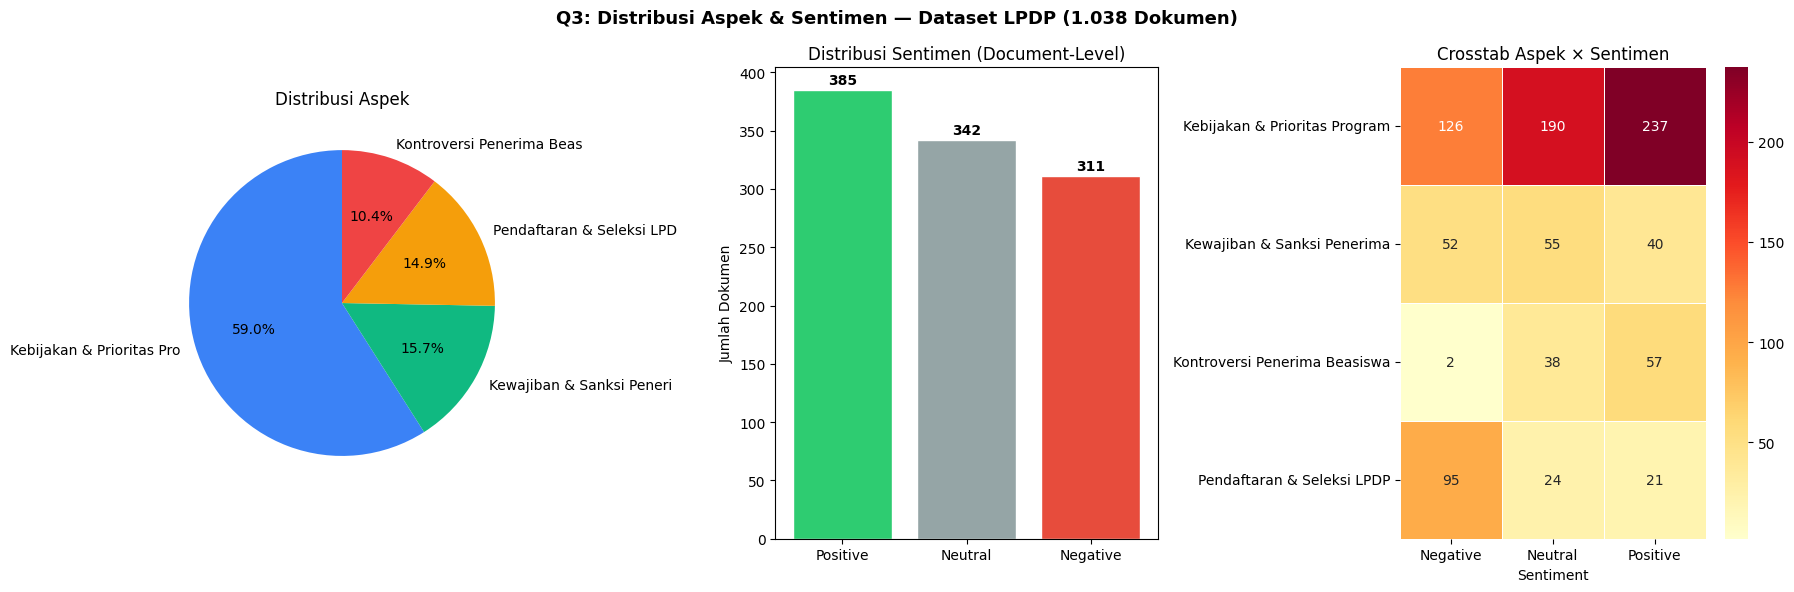

Visualisasi disimpan: q3_distribusi_aspek_sentimen.png
Persentase Sentimen per Aspek:
Sentiment                      Negative  Neutral  Positive
label_name                                                
Kebijakan & Prioritas Program      22.8     34.4      42.9
Kewajiban & Sanksi Penerima        35.4     37.4      27.2
Kontroversi Penerima Beasiswa       2.1     39.2      58.8
Pendaftaran & Seleksi LPDP         67.9     17.1      15.0


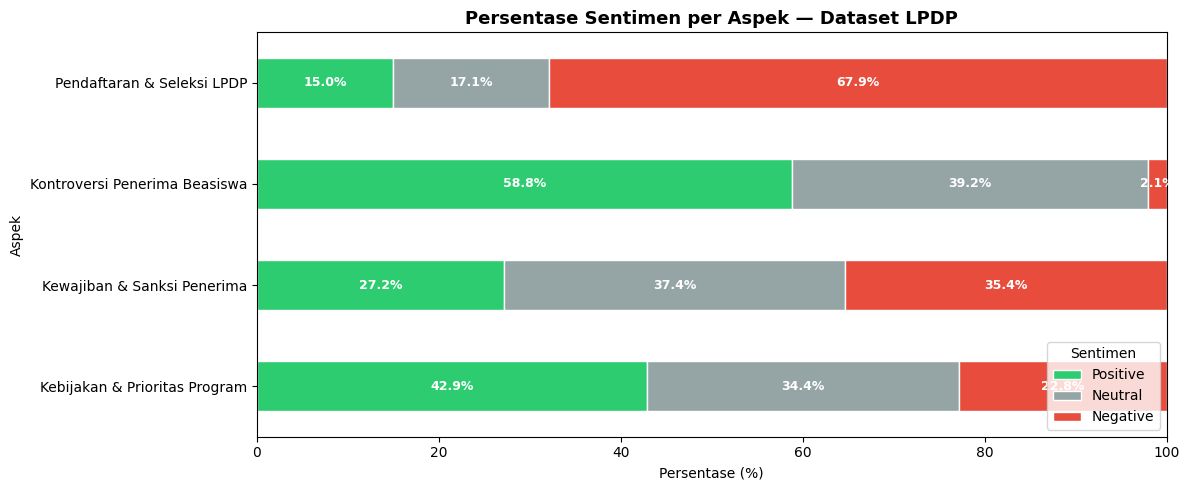

Visualisasi disimpan: q3_persentase_sentimen_per_aspek.png


In [10]:
# Q3 — Visualisasi distribusi aspek dan sentimen dari dataset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

DATA_PATH_BERT  = r"c:\Coding\pba\PBA-TIXID-SentimentAnalysis\Week-11\dataset_lpdp_preprocessed_bert.csv"
df3 = pd.read_csv(DATA_PATH_BERT)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Q3: Distribusi Aspek & Sentimen — Dataset LPDP (1.038 Dokumen)", fontsize=13, fontweight="bold")

# Plot 1: Distribusi aspek (pie)
aspect_counts = df3["label_name"].value_counts()
axes[0].pie(aspect_counts.values, labels=[l[:25] for l in aspect_counts.index],
            autopct="%1.1f%%", startangle=90, colors=["#3B82F6","#10B981","#F59E0B","#EF4444"])
axes[0].set_title("Distribusi Aspek")

# Plot 2: Distribusi sentimen (bar)
sent_counts = df3["Sentiment"].value_counts()
colors_sent = {"Positive":"#2ecc71","Neutral":"#95a5a6","Negative":"#e74c3c"}
axes[1].bar(sent_counts.index, sent_counts.values,
            color=[colors_sent.get(s,"gray") for s in sent_counts.index], edgecolor="white")
axes[1].set_title("Distribusi Sentimen (Document-Level)")
axes[1].set_ylabel("Jumlah Dokumen")
for i,(v) in enumerate(sent_counts.values):
    axes[1].text(i, v+5, str(v), ha="center", fontweight="bold")

# Plot 3: Heatmap Aspek x Sentimen
ct = pd.crosstab(df3["label_name"], df3["Sentiment"])
sns.heatmap(ct, ax=axes[2], annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
axes[2].set_title("Crosstab Aspek × Sentimen")
axes[2].set_ylabel("")

plt.tight_layout()
plt.savefig("q3_distribusi_aspek_sentimen.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi disimpan: q3_distribusi_aspek_sentimen.png")

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print("Persentase Sentimen per Aspek:")
print(ct_pct.round(1))

# Visualisasi persentase sentimen per aspek
fig2, ax = plt.subplots(figsize=(12, 5))

ordered_cols = [c for c in ["Positive", "Neutral", "Negative"] if c in ct_pct.columns]
colors_pct = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}

ct_pct[ordered_cols].plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=[colors_pct[c] for c in ordered_cols],
    edgecolor="white"
)

ax.set_title("Persentase Sentimen per Aspek — Dataset LPDP", fontsize=13, fontweight="bold")
ax.set_xlabel("Persentase (%)")
ax.set_ylabel("Aspek")
ax.set_xlim(0, 100)
ax.legend(title="Sentimen", loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=9, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig("q3_persentase_sentimen_per_aspek.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi disimpan: q3_persentase_sentimen_per_aspek.png")

## Q4. Contoh Tabel Anotasi ABSA

Berikut 3 contoh dokumen nyata dari dataset beserta anotasi ABSA per kalimat.
Anotasi ini menunjukkan bagaimana satu dokumen bisa memiliki beberapa aspek dengan polaritas berbeda.


In [11]:
# Q4 — Anotasi ABSA: kalimat diambil langsung dari Content dokumen di dataset
import pandas as pd
import re

DATA_PATH_BERT = r'c:\Coding\pba\PBA-TIXID-SentimentAnalysis\Week-11\dataset_lpdp_preprocessed_bert.csv'
df4 = pd.read_csv(DATA_PATH_BERT)

def split_sentences(text):
    """Pecah teks menjadi kalimat-kalimat."""
    if not isinstance(text, str):
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sentences if len(s.strip()) > 20]

# Pilih 3 dokumen representatif dari dataset
contoh_docs = [
    df4[(df4['label_name']=='Kebijakan & Prioritas Program') & (df4['Sentiment']=='Positive')].iloc[0],
    df4[(df4['label_name']=='Kewajiban & Sanksi Penerima')   & (df4['Sentiment']=='Negative')].iloc[2],
    df4[(df4['label_name']=='Pendaftaran & Seleksi LPDP')    & (df4['Sentiment']=='Negative')].iloc[0],
]

# Anotasi sentence-level:
# - Kalimat diambil dari split_sentences(doc['text_bert']) — kalimat asli artikel
# - Index kalimat merujuk ke urutan kalimat di dokumen tersebut
# - Aspek, polaritas, dan indikator dianotasi manual berdasarkan isi kalimat
anotasi = [
    # Dokumen 1 — Kebijakan & Prioritas Program (Positive)
    # Sumber: split_sentences(doc['text_bert'])[2], [4], [5]
    [
        (2, 'Kebijakan & Prioritas Program', 'Positif',
         'fokus(+), top of the top talenta(+), pendidikan tinggi top dunia(+)'),
        (4, 'Kebijakan & Prioritas Program', 'Positif',
         'memberikan kesempatan yang sama(+), mengakses pendidikan tinggi(+)'),
        (5, 'Kebijakan & Prioritas Program', 'Positif',
         'beasiswa afirmasi(+), inklusif untuk kelompok rentan(+)'),
    ],
    # Dokumen 2 — Kewajiban & Sanksi Penerima (Negative)
    # Sumber: split_sentences(doc['text_bert'])[1], [4], [7]
    [
        (1, 'Kewajiban & Sanksi Penerima', 'Negatif',
         'viral(-), belum sepenuhnya mematuhi aturan(-), dugaan pelanggaran(-)'),
        (4, 'Pendaftaran & Seleksi LPDP',   'Negatif',
         'memperketat seleksi(-implisit ada masalah), belum mematuhi aturan(-)'),
        (7, 'Kewajiban & Sanksi Penerima', 'Negatif',
         'integritas dan komitmen harus diuji(-), bukan sekadar akademik(-)'),
    ],
    # Dokumen 3 — Pendaftaran & Seleksi LPDP (Negative)
    # Sumber: split_sentences(doc['text_bert'])[0], [1], [2]
    [
        (0, 'Kewajiban & Sanksi Penerima', 'Negatif',
         'sanctioned(-), failing to fulfill obligations(-), 44 awardees(-)'),
        (1, 'Kewajiban & Sanksi Penerima', 'Negatif',
         'required to return scholarship funds(-), still under investigation(-)'),
        (2, 'Kewajiban & Sanksi Penerima', 'Negatif',
         'more than 600 awardees(-), potensi pelanggaran skala besar(-)'),
    ],
]

# Tampilkan tabel anotasi
for i, (doc, ann) in enumerate(zip(contoh_docs, anotasi)):
    sentences = split_sentences(str(doc['text_bert']))
    print(f"\n{'='*75}")
    print(f"DOKUMEN {i+1}: {doc['Title'][:80]}")
    print(f"Aspek Dominan : {doc['label_name']} | Sentimen Dok: {doc['Sentiment']}")
    print(f"{'='*75}")
    print(f"{'Kalimat (dari dataset)':<52} {'Aspek':<32} {'Pol':>7}  Indikator")
    print('-' * 140)
    for sent_idx, aspek, pol, indikator in ann:
        kalimat = sentences[sent_idx] if sent_idx < len(sentences) else ''
        print(f"{kalimat[:50]:<52} {aspek[:30]:<32} {pol:>7}  {indikator}")



DOKUMEN 1: Dirut: Beasiswa LPDP bersifat inklusif, fokus cari talenta unggul - ANTARA News
Aspek Dominan : Kebijakan & Prioritas Program | Sentimen Dok: Positive
Kalimat (dari dataset)                               Aspek                                Pol  Indikator
--------------------------------------------------------------------------------------------------------------------------------------------
“LPDP itu benar-benar fokus untuk mencari top of t   Kebijakan & Prioritas Program    Positif  fokus(+), top of the top talenta(+), pendidikan tinggi top dunia(+)
Sudarto mengatakan LPDP berusaha memberikan kesemp   Kebijakan & Prioritas Program    Positif  memberikan kesempatan yang sama(+), mengakses pendidikan tinggi(+)
Salah satu upaya yang dilakukan juga mencakup beas   Kebijakan & Prioritas Program    Positif  beasiswa afirmasi(+), inklusif untuk kelompok rentan(+)

DOKUMEN 2: Kritisi penerima LPDP, DPR minta perketat seleksi beasiswa LPDP - ANTARA News
Aspek Dominan : Kewajiban

## Q5. Metode Lexicon vs Machine Learning dalam ABSA

| Dimensi | Lexicon-Based | IndoBERT (ML) |
|---------|---------------|---------------|
| Data latih | Tidak butuh | Sudah pre-trained |
| Transparansi | Tinggi (skor per kata) | Rendah (black box) |
| Konteks | Terbatas (window) | Penuh (bidirectional) |
| Akurasi (est.) | ~60-65% | ~75-80% |
| Kecepatan | Sangat cepat | Lambat (GPU optimal) |
| Domain baru | Tambah lexicon | Perlu fine-tuning |

**Rekomendasi untuk LPDP**: IndoBERT sebagai model utama, lexicon sebagai baseline & interpretability tool.


In [12]:
# Q5 — Perbandingan Lexicon vs ML: uji coba pada beberapa kalimat
# (akan dijalankan penuh setelah model loaded di section 4 & lexicon section L1)

kalimat_uji = [
    ("Proses seleksi LPDP sangat transparan dan kompetitif.", "Positive"),
    ("Banyak penerima melanggar kewajiban untuk kembali ke Indonesia.", "Negative"),
    ("Kebijakan LPDP tidak adil bagi masyarakat kurang mampu.", "Negative"),
    ("Program ini mendukung pengembangan SDM yang berkualitas.", "Positive"),
    ("LPDP memberikan sanksi kepada puluhan penerima beasiswa.", "Negative"),
    ("Seleksi dilakukan secara ketat dan berdasarkan prestasi akademik.", "Positive"),
]

print("Contoh kalimat uji yang akan digunakan untuk perbandingan Lexicon vs ML:")
print(f"{'No':<4} {'Kalimat':<60} {'Label True'}")
print("-"*80)
for i, (kal, label) in enumerate(kalimat_uji, 1):
    print(f"{i:<4} {kal[:58]:<60} {label}")
print()
print("→ Jalankan Section L1-L6 (Lexicon) untuk melihat perbandingan penuh.")
print("→ Jalankan Section 4-8  (IndoBERT) untuk melihat hasil ML.")


Contoh kalimat uji yang akan digunakan untuk perbandingan Lexicon vs ML:
No   Kalimat                                                      Label True
--------------------------------------------------------------------------------
1    Proses seleksi LPDP sangat transparan dan kompetitif.        Positive
2    Banyak penerima melanggar kewajiban untuk kembali ke Indon   Negative
3    Kebijakan LPDP tidak adil bagi masyarakat kurang mampu.      Negative
4    Program ini mendukung pengembangan SDM yang berkualitas.     Positive
5    LPDP memberikan sanksi kepada puluhan penerima beasiswa.     Negative
6    Seleksi dilakukan secara ketat dan berdasarkan prestasi ak   Positive

→ Jalankan Section L1-L6 (Lexicon) untuk melihat perbandingan penuh.
→ Jalankan Section 4-8  (IndoBERT) untuk melihat hasil ML.


## Q6. Implementasi ABSA — IndoBERT + Lexicon

Implementasi penuh ABSA menggunakan dua pendekatan:
- **IndoBERT** (`mdhugol/indonesia-bert-sentiment-classification`) — model ML berbasis transformer
- **Lexicon-based** — kamus sentimen domain LPDP dengan penanganan negasi & intensifier

Pipeline: Load dataset → Definisi aspek → Deteksi aspek per kalimat → Klasifikasi sentimen → Evaluasi & visualisasi


### Q6.1 — Install & Import


In [13]:
!pip install transformers torch scikit-learn pandas matplotlib seaborn


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import defaultdict

### Q6.2 — Load Dataset


In [15]:
DATA_PATH = r"c:\Coding\pba\PBA-TIXID-SentimentAnalysis\Week-11\dataset_lpdp_preprocessed_bert.csv" # sesuaikan lokasi file

df = pd.read_csv(DATA_PATH)

print(f"Shape       : {df.shape}")
print(f"Kolom       : {df.columns.tolist()}")
print()
print("Distribusi Sentiment (label dokumen):")
print(df["Sentiment"].value_counts())
print()
print("Distribusi label_name (Aspek dokumen):")
print(df["label_name"].value_counts())
print()
print("Cross-tabulation Aspek x Sentimen:")
import pandas as pd
print(pd.crosstab(df["label_name"], df["Sentiment"]))


Shape       : (1038, 15)
Kolom       : ['doc_id', 'Title', 'Release Date', 'URL', 'Publisher', 'PiC', 'Valid?', 'Sentiment', 'Notes', 'Actual_URL', 'Content', 'label_4', 'label_name', 'token_count', 'text_bert']

Distribusi Sentiment (label dokumen):
Sentiment
Positive    385
Neutral     342
Negative    311
Name: count, dtype: int64

Distribusi label_name (Aspek dokumen):
label_name
Kebijakan & Prioritas Program    553
Kewajiban & Sanksi Penerima      147
Pendaftaran & Seleksi LPDP       140
Kontroversi Penerima Beasiswa     97
Name: count, dtype: int64

Cross-tabulation Aspek x Sentimen:
Sentiment                      Negative  Neutral  Positive
label_name                                                
Kebijakan & Prioritas Program       126      190       237
Kewajiban & Sanksi Penerima          52       55        40
Kontroversi Penerima Beasiswa         2       38        57
Pendaftaran & Seleksi LPDP           95       24        21


### Q6.3 — Definisi Aspek & Kata Kunci


In [16]:
ASPECT_KEYWORDS = {
  "Kebijakan & Prioritas Program": [
        "kebijakan", "prioritas", "program", "anggaran", "dana", "pemerintah",
        "menteri", "regulasi", "aturan", "ketentuan", "skema", "target",
        "rencana", "strategi", "alokasi", "lpdp", "beasiswa"
    ],
    "Pendaftaran & Seleksi LPDP": [
        "seleksi", "daftar", "pendaftaran", "tes", "wawancara", "lolos",
        "gagal", "syarat", "persyaratan", "administrasi", "berkas", "dokumen",
        "proses", "tahap", "kompetitif", "ketat", "kuota", "penerimaan"
    ],
    "Kewajiban & Sanksi Penerima": [
        "kewajiban", "sanksi", "wajib", "kembali", "kontribusi", "pulang",
        "negara", "pengabdian", "denda", "pelanggaran", "komitmen", "perjanjian",
        "ikatan dinas", "alumni", "lulusan"
    ],
    "Kontroversi Penerima Beasiswa": [
        "kontroversi", "masalah", "kasus", "viral", "polemik", "kritik",
        "protes", "dugaan", "skandal", "penyalahgunaan", "nepotisme", "korupsi",
        "kolusi", "tidak adil", "diskriminasi"
    ]
}

LABEL_MAP = {
    "Positive": "Positive",
    "Neutral" : "Neutral",
    "Negative": "Negative"
}

print("Aspek yang didefinisikan:")
for aspect, keywords in ASPECT_KEYWORDS.items():
  print(f"  [{aspect}] → {len(keywords)} kata kunci")

Aspek yang didefinisikan:
  [Kebijakan & Prioritas Program] → 17 kata kunci
  [Pendaftaran & Seleksi LPDP] → 18 kata kunci
  [Kewajiban & Sanksi Penerima] → 15 kata kunci
  [Kontroversi Penerima Beasiswa] → 15 kata kunci


### Q6.4 — Load Model IndoBERT


In [17]:
MODEL_NAME = "mdhugol/indonesia-bert-sentiment-classification"

print(f"Loading model: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

sentiment_pipeline = pipeline(
  "text-classification",
  model = model,
  tokenizer = tokenizer,
  truncation = True,
  max_length = 512
)

MODEL_LABEL_MAP = {
  "LABEL_0": "Positive",
  "LABEL_1": "Neutral",
  "LABEL_2": "Negative",
}

print("Model siap!")

Loading model: mdhugol/indonesia-bert-sentiment-classification


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9948.26it/s]

Model siap!


### Q6.5 — Fungsi ABSA

#### 6.5a. Deteksi Aspek per Kalimat


In [18]:
def split_sentences(text):
  """Memecah teks menjadi kalimat-kalimat."""
  if not isinstance(text, str):
    return []
  # Split berdasarkan tanda titik, tanda tanya, tanda seru
  sentences = re.split(r'(?<=[.!?])\s+', text.strip())
  # Filter kalimat terlalu pendek
  return [s.strip() for s in sentences if len(s.strip()) > 20]

def detect_aspects(sentence, aspect_keywords):
  """
  Deteksi aspek apa saja yang muncul dalam sebuah kalimat
    berdasarkan kata kunci.
    Return: list aspek yang terdeteksi
  """
  sentence_lower = sentence.lower()
  detected = []
  for aspect, keywords in aspect_keywords.items():
    for kw in keywords:
      if kw in sentence_lower:
        detected.append(aspect)
        break
  return detected

def predict_sentiment(text, pipeline_model, label_map):
  """Prediksi sentimen sebuah teks menggunakan IndoBERT"""
  try:
    result = pipeline_model(text[:512])
    raw_label = result[0]['label']
    score = result[0]['score']
    label = label_map.get(raw_label, raw_label)
    return label, round(score, 4)
  except Exception as e:
    return "Neutral", 0.0
  

print("Fungsi ABSA siap!")

Fungsi ABSA siap!


#### 6.5b. Pipeline ABSA Utama (dengan Checkpoint)


In [19]:
import json
from pathlib import Path

ckpt = Path("checkpoint_absa.json")
if ckpt.exists():
    ckpt.unlink()
    print("Checkpoint corrupt dihapus, siap mulai dari awal.")
else:
    print("Tidak ada checkpoint.")

ABSA_CHECKPOINT_FILE = Path("checkpoint_absa.json")

def save_absa_checkpoint(results, last_idx):
  with open(ABSA_CHECKPOINT_FILE, "w", encoding="utf-8") as f:
    json.dump({"last_idx": last_idx, "results": results}, f, ensure_ascii=False, default=str)

def load_absa_checkpoint():
  if ABSA_CHECKPOINT_FILE.exists():
    try:
      with open(ABSA_CHECKPOINT_FILE, "r", encoding="utf-8") as f:
        data = json.load(f)
        print(f"[Checkpoint ditemukan] Melanjutkan dari dokumen ke-{data['last_idx'] + 1}")
        print(f"  Data tersimpan sebelumnya: {len(data['results'])} baris")
        return data["results"], data["last_idx"]
    except json.JSONDecodeError:
      print("[Checkpoint corrupt] Menghapus dan mulai dari awal.")
      ABSA_CHECKPOINT_FILE.unlink()
      return [], -1
  else:
    print("[Tidak ada checkpoint] Mulai dari awal.")
    return [], -1
  
def clear_absa_checkpoint():
  if ABSA_CHECKPOINT_FILE.exists():
    ABSA_CHECKPOINT_FILE.unlink()
    print("Checkpoint dihapus.")

def run_absa_pipeline(
    df,
    text_col = "text_bert",
    doc_label_col = "Sentiment",
    aspect_col = "label_name",
    aspect_keywords = ASPECT_KEYWORDS,
    sentiment_pipe = None,
    label_map = MODEL_LABEL_MAP, 
    max_docs = None,
    checkpoint_every = 10
):
  sample_df = df.head(max_docs).reset_index(drop=True) if max_docs else df.reset_index(drop=True)
  total = len(sample_df)

  results, last_done_idx = load_absa_checkpoint()

  print(f"Memproses {total} dokumen (mulai dari idx {last_done_idx + 1})...")

  for i in range(last_done_idx + 1, total):
    row = sample_df.iloc[i]
    doc_id = str(row.get("doc_id", i))
    text = row[text_col]
    doc_label = row[doc_label_col] # sentimen level dokumen (ground truth)
    doc_aspect = row[aspect_col] # aspek level dokumen (ground truth)

    sentences = split_sentences(text)

    for sent in sentences:
      aspects_found = detect_aspects(sent, aspect_keywords)

      if not aspects_found:
        continue # lewati kalimat yang tidak mengandung aspek

      # prediksi sentimen untuk kalimat ini
      pred_sentiment, confidence = predict_sentiment(
        sent, sentiment_pipe, label_map
      )

      for aspect in aspects_found:
        results.append({
          "doc_id": doc_id,
          "sentence": sent,
          "aspect_detected": aspect,
          "aspect_ground_truth": doc_aspect,
          "sentiment_predicted": pred_sentiment,
          "sentiment_doc_label": doc_label,
          "confidence": confidence
        })

    if (i + 1) % checkpoint_every == 0:
      save_absa_checkpoint(results, i)
      print(f"  [Checkpoint] {i + 1}/{total} dokumen selesai, {len(results)} baris tersimpan")

  absa_df = pd.DataFrame(results)
  print(f"\nSelesai! Total pasangan (kalimat x aspek): {len(absa_df)}")

  clear_absa_checkpoint()
  
  return absa_df


print("Pipeline utama siap!")

Checkpoint corrupt dihapus, siap mulai dari awal.
Pipeline utama siap!


### Q6.6 — Jalankan ABSA Pipeline

> ⚠️ **Catatan**: Untuk test awal, gunakan `max_docs=50`. Setelah yakin hasilnya benar, hapus parameter `max_docs` untuk memproses semua data.


In [20]:
absa_results = run_absa_pipeline(
  df = df,
  text_col = "text_bert",
  doc_label_col = "Sentiment",
  aspect_col = "label_name",
  aspect_keywords = ASPECT_KEYWORDS,
  sentiment_pipe = sentiment_pipeline,
  label_map = MODEL_LABEL_MAP,
  max_docs = None,
  checkpoint_every = 10
)

print("\nSample hasil ABSA:")
print(absa_results[[
  "doc_id", "sentence", "aspect_detected", "sentiment_predicted", "sentiment_doc_label", "confidence"
]].head(10).to_string())

[Tidak ada checkpoint] Mulai dari awal.
Memproses 1038 dokumen (mulai dari idx 0)...
  [Checkpoint] 10/1038 dokumen selesai, 223 baris tersimpan
  [Checkpoint] 20/1038 dokumen selesai, 489 baris tersimpan
  [Checkpoint] 30/1038 dokumen selesai, 788 baris tersimpan
  [Checkpoint] 40/1038 dokumen selesai, 1097 baris tersimpan
  [Checkpoint] 50/1038 dokumen selesai, 1436 baris tersimpan
  [Checkpoint] 60/1038 dokumen selesai, 1964 baris tersimpan
  [Checkpoint] 70/1038 dokumen selesai, 2282 baris tersimpan
  [Checkpoint] 80/1038 dokumen selesai, 2594 baris tersimpan
  [Checkpoint] 90/1038 dokumen selesai, 3059 baris tersimpan
  [Checkpoint] 100/1038 dokumen selesai, 3308 baris tersimpan
  [Checkpoint] 110/1038 dokumen selesai, 3507 baris tersimpan
  [Checkpoint] 120/1038 dokumen selesai, 3755 baris tersimpan
  [Checkpoint] 130/1038 dokumen selesai, 4004 baris tersimpan
  [Checkpoint] 140/1038 dokumen selesai, 4278 baris tersimpan
  [Checkpoint] 150/1038 dokumen selesai, 4465 baris tersimp

In [21]:
absa_results.to_csv("absa_results_lpdp.csv", index=False)
print("Hasil ABSA disimpan ke: absa_results_lpdp.csv")
print(f"Total baris: {len(absa_results)}")

Hasil ABSA disimpan ke: absa_results_lpdp.csv
Total baris: 26358


### Q6.7 — Analisis Hasil ABSA


In [22]:
# Distribusi aspek yang terdeteksi
print("=" * 50)
print("DISTRIBUSI ASPEK YANG TERDETEKSI")
print("=" * 50)
print(absa_results["aspect_detected"].value_counts())

print()
print("=" * 50)
print("DISTRIBUSI SENTIMEN PER ASPEK")
print("=" * 50)
pivot = pd.crosstab(
  absa_results["aspect_detected"],
  absa_results["sentiment_predicted"]
)
print(pivot)

DISTRIBUSI ASPEK YANG TERDETEKSI
aspect_detected
Kebijakan & Prioritas Program    13449
Kewajiban & Sanksi Penerima       6569
Pendaftaran & Seleksi LPDP        4803
Kontroversi Penerima Beasiswa     1537
Name: count, dtype: int64

DISTRIBUSI SENTIMEN PER ASPEK
sentiment_predicted            Negative  Neutral  Positive
aspect_detected                                           
Kebijakan & Prioritas Program       673    12168       608
Kewajiban & Sanksi Penerima         600     5628       341
Kontroversi Penerima Beasiswa       244     1254        39
Pendaftaran & Seleksi LPDP          211     4435       157


In [23]:
# Rata-rata confidence per aspek
print("=" * 50)
print("RATA-RATA CONFIDENCE PER ASPEK")
print("=" * 50)
print(absa_results.groupby("aspect_detected")["confidence"].mean().round(4))

RATA-RATA CONFIDENCE PER ASPEK
aspect_detected
Kebijakan & Prioritas Program    0.9323
Kewajiban & Sanksi Penerima      0.9136
Kontroversi Penerima Beasiswa    0.9052
Pendaftaran & Seleksi LPDP       0.9503
Name: confidence, dtype: float64


### Q6.8 — Visualisasi


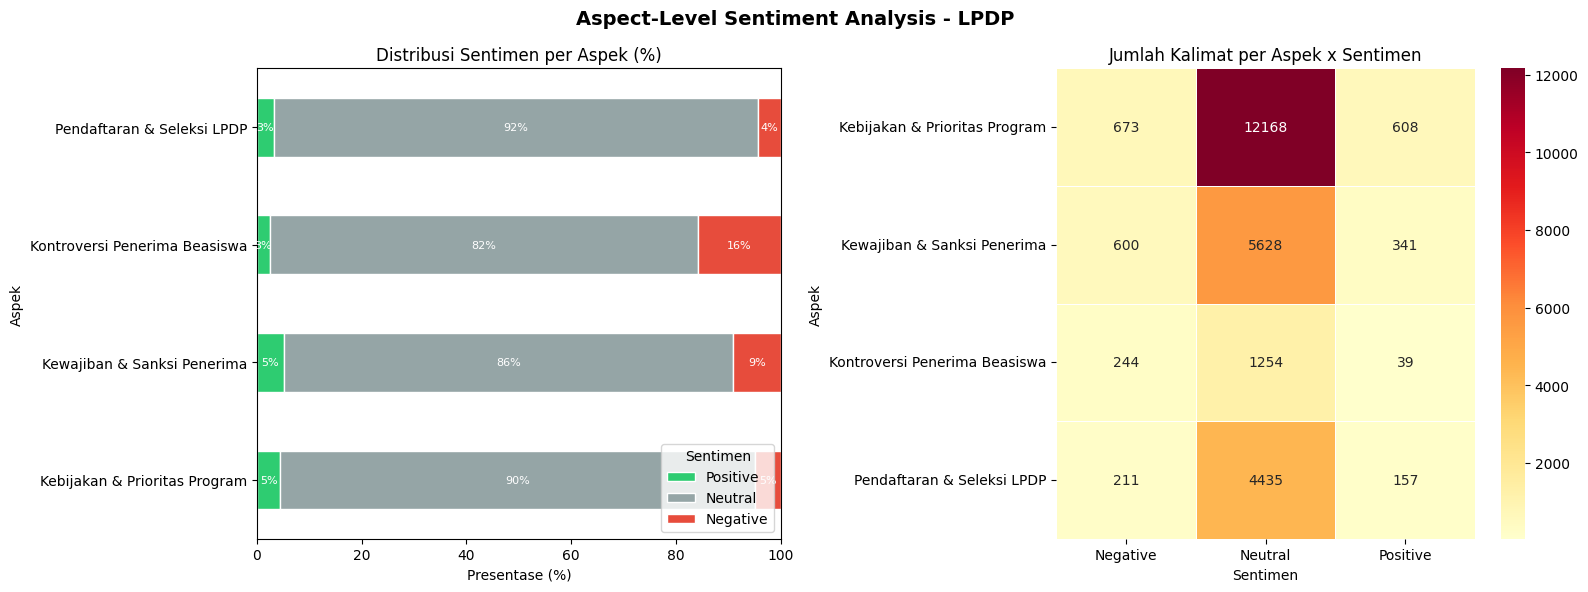

Visualisasi disimpan ke: absa_visualisasi.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Aspect-Level Sentiment Analysis - LPDP", fontsize=14, fontweight="bold")

# Plot 1: Distribusi sentimen per aspek
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
colors = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}

ordered_cols = [c for c in ["Positive", "Neutral", "Negative"] if c in pivot_pct.columns]
pivot_pct[ordered_cols].plot(
  kind = "barh",
  stacked = True,
  ax = axes[0],
  color = [colors[c] for c in ordered_cols],
  edgecolor = "white"
)
axes[0].set_title("Distribusi Sentimen per Aspek (%)", fontsize=12)
axes[0].set_xlabel("Presentase (%)")
axes[0].set_ylabel("Aspek")
axes[0].legend(title="Sentimen", loc="lower right")
axes[0].set_xlim(0, 100)

for container in axes[0].containers:
  axes[0].bar_label(container, fmt='%.0f%%',
  label_type='center', fontsize=8, color='white')

# Plot 2: Heatmap jumlah kalimat per aspek x sentimen
sns.heatmap(
  pivot,
  ax = axes[1],
  annot = True,
  fmt = "d",
  cmap = "YlOrRd",
  linewidths = 0.5
)
axes[1].set_title("Jumlah Kalimat per Aspek x Sentimen", fontsize=12)
axes[1].set_xlabel("Sentimen")
axes[1].set_ylabel("Aspek")

plt.tight_layout()
plt.savefig("absa_visualisasi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi disimpan ke: absa_visualisasi.png")

In [25]:
# sentimen dominan per aspek
print("=" * 50)
print("SENTIMEN DOMINAN PER ASPEK")
print("=" * 50)

dominant = (
  absa_results
  .groupby(["aspect_detected", "sentiment_predicted"])
  .size()
  .reset_index(name="count")
  .sort_values(["aspect_detected", "count"], ascending=[True, False])
  .groupby("aspect_detected")
  .first()
  .reset_index()
)

for _, row in dominant.iterrows():
  print(f"  [{row['aspect_detected']}]")
  print(f"  → Sentimen dominan: {row['sentiment_predicted']} ({row['count']} kalimat)")
  print()

SENTIMEN DOMINAN PER ASPEK
  [Kebijakan & Prioritas Program]
  → Sentimen dominan: Neutral (12168 kalimat)

  [Kewajiban & Sanksi Penerima]
  → Sentimen dominan: Neutral (5628 kalimat)

  [Kontroversi Penerima Beasiswa]
  → Sentimen dominan: Neutral (1254 kalimat)

  [Pendaftaran & Seleksi LPDP]
  → Sentimen dominan: Neutral (4435 kalimat)



### Q6.9 — Evaluasi: ABSA vs Label Dokumen

Karena tidak ada ground truth level kalimat, sentimen mayoritas per dokumen dari hasil ABSA dibandingkan dengan label sentimen document-level dari dataset asli.


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

# Agregasi: ambil sentimen mayoritas per dokumen dari hasil ABSA lalu bandingkan dengan label dokumen asli

doc_sentiment_absa = (
  absa_results
  .groupby(["doc_id", "sentiment_predicted"])
  .size()
  .reset_index(name="count")
  .sort_values(["doc_id", "count"], ascending=[True, False])
  .groupby("doc_id")
  .first()
  .reset_index().rename(columns={"sentiment_predicted": "absa_majority_sentiment"})
)

# gabungkan dengan label asli
doc_ground_truth = (
  absa_results
  .groupby("doc_id")["sentiment_doc_label"]
  .first()
  .reset_index()
)

eval_df = doc_sentiment_absa.merge(doc_ground_truth, on="doc_id")

print("Sample perbandingan ABSA vs label dokumen:")
print(eval_df[["doc_id", "absa_majority_sentiment", "sentiment_doc_label"]].head(10).to_string())

Sample perbandingan ABSA vs label dokumen:
  doc_id absa_majority_sentiment sentiment_doc_label
0      0                 Neutral            Negative
1      1                 Neutral            Negative
2     10                 Neutral            Negative
3    100                 Neutral            Negative
4   1000                Negative            Negative
5   1001                 Neutral            Negative
6   1002                 Neutral             Neutral
7   1003                 Neutral             Neutral
8   1004                 Neutral            Negative
9   1005                 Neutral             Neutral


In [27]:
# classification report
y_true = eval_df["sentiment_doc_label"]
y_pred = eval_df["absa_majority_sentiment"]

print("=" * 50)
print("EVALUASI: ABSA vs Document-Level Label")
print("=" * 50)
print()
print(classification_report(y_true, y_pred, zero_division=0))

acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

EVALUASI: ABSA vs Document-Level Label

              precision    recall  f1-score   support

    Negative       0.64      0.02      0.04       309
     Neutral       0.33      0.99      0.50       341
    Positive       0.71      0.01      0.03       384

    accuracy                           0.34      1034
   macro avg       0.56      0.34      0.19      1034
weighted avg       0.57      0.34      0.19      1034

Accuracy: 0.3395


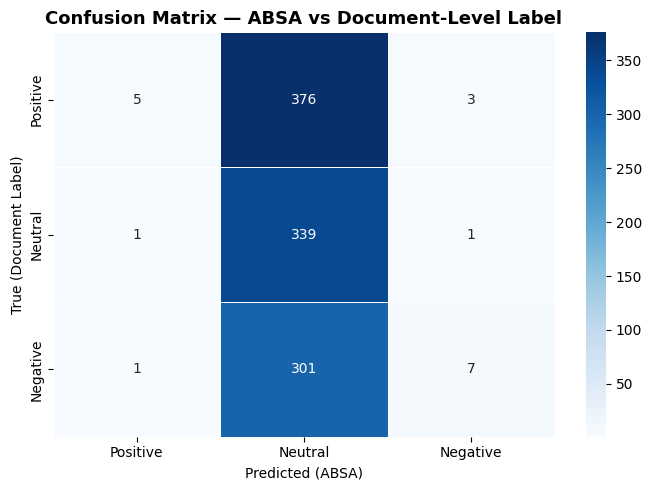

Confusion matrix disimpan ke: absa_confusion_matrix.png


In [28]:
# confusion matrix
labels = ["Positive", "Neutral", "Negative"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
  cm,
  annot = True,
  fmt = "d",
  cmap = "Blues",
  xticklabels = labels,
  yticklabels = labels,
  linewidths = 0.5
)
plt.title("Confusion Matrix — ABSA vs Document-Level Label", fontsize=13, fontweight="bold")
plt.xlabel("Predicted (ABSA)")
plt.ylabel("True (Document Label)")
plt.tight_layout()
plt.savefig("absa_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix disimpan ke: absa_confusion_matrix.png")

### Q6.10 — Ringkasan Hasil


In [29]:
print("=" * 55)
print("RINGKASAN HASIL ABSA — LPDP")
print("=" * 55)

print(f"\nTotal dokumen diproses: {absa_results['doc_id'].nunique()}")
print(f"Total pasangan kalimat-aspek: {len(absa_results)}")

print("\nJumlah kalimat per aspek:")
print(absa_results['aspect_detected'].value_counts().to_string())

print("\nSentimen keseluruhan dari ABSA:")
print(absa_results['sentiment_predicted'].value_counts().to_string())

print("\nFile output:")
print("  - absa_results_lpdp.csv     (data hasil ABSA)")
print("  - absa_visualisasi.png     (distribusi sentimen per aspek)")
print("  - absa_confusion_matrix.csv     (confusion matrix evaluasi)")

total = len(absa_results)
pct = absa_results['sentiment_predicted'].value_counts() / total * 100

print("Persentase Sentimen Keseluruhan dari ABSA:")
for sentiment, count in absa_results['sentiment_predicted'].value_counts().items():
    print(f"  {sentiment:<10} : {count:>6} kalimat ({pct[sentiment]:.1f}%)")

RINGKASAN HASIL ABSA — LPDP

Total dokumen diproses: 1034
Total pasangan kalimat-aspek: 26358

Jumlah kalimat per aspek:
aspect_detected
Kebijakan & Prioritas Program    13449
Kewajiban & Sanksi Penerima       6569
Pendaftaran & Seleksi LPDP        4803
Kontroversi Penerima Beasiswa     1537

Sentimen keseluruhan dari ABSA:
sentiment_predicted
Neutral     23485
Negative     1728
Positive     1145

File output:
  - absa_results_lpdp.csv     (data hasil ABSA)
  - absa_visualisasi.png     (distribusi sentimen per aspek)
  - absa_confusion_matrix.csv     (confusion matrix evaluasi)
Persentase Sentimen Keseluruhan dari ABSA:
  Neutral    :  23485 kalimat (89.1%)
  Negative   :   1728 kalimat (6.6%)
  Positive   :   1145 kalimat (4.3%)
